# PyTorch Computer vision 

Computer vision is the art of teaching computer to see.

For example, it could involve building a model to classify whether a photo is of a cat or dog.

Or whether a photo is of a cat, dog chicken (Multi-class classification).

Or identifying where a car appears in a video frame(object detection). 

Or Figure out where different objects in an image can be separated (panoptic segmentation). 

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-problems.png)

### Where does computer vision get used?

If you use a smartphone, you've already used computer vision.

Canera and photo apps use computer vision to enhance and sort images. 

modern cars use computer vision to avoid other cars and stay within lane lines.

Manufacturers use computer vision to identify defects in various products.

security cameras use Computer vision to detect potential intruders.

In essence, anythings that can described in a visual sense can be potential computer vision problem.


### What we're goint to cover?

| Topic | Contents | 
| ---- | ---- |
| 0. Computer vision libraries in PyTorch | PyTorch has a bunch of built-in helpful computer vision libraries, let's check them out.| 
| 1. Load Data | To practice computer vision, we'll start with some images of different pieces of clothing from [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). |
| 2. Prepare data | We've got some images, let's load them in with a [PyTorch DataLoader](https://pytorch.org/docs/stable/data.html) so we can use them with our training loop. |
| 3. Model 0:Building a baseline model | Here we'll create a multi-class classification model to learn patterns in the data, we'll also choose a **loss function, optimizer** and build a **training loop**. | 
| 4. Making prediction and evaluting model 0 | Let's make some predictions with our baseline model and evaluate them. |
| 5. Setup device agnostic code for future models | It's best practice to write device-agnostic code, so let's set it up. |
| 6. Model 1: Adding non-linearity | Experimenting is a large part of machine learning, let's try and improve upon our baseline model by adding non-linear layers. |
| 7. Model 2: Convolutional Neural Network (CNN) | Time to get computer vision specific and introduce the powerful convolutional neural network architecture. |
| 8. Comparing our models | 	We've built three different models, let's compare them. |
| 9. Evaluating our best model | Let's make some predictons on random images and evaluate our best model. |
| 10. Making a confusion matrix	 | A confusion matrix is a great way to evaluate a classification model, let's see how we can make one. |
| 11. Saving and loading the best performing model| Since we might want to use our model for later, let's save it and make sure it loads back in correctly. |

## Computer vision libraries in PyTorch 

| PyTorch module | What does it do? |
| ---- | ---- |
| [torchvision](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems.|
| [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets.](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets) |
| [torchvision.models](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch. |
| [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iteralbe over a dataset (created with `torch.utils.data.Dataset`). |

In [1]:
import torch 
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt 

# Check versions
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.0.1
torchvision version: 0.15.2


## 1. Getting a Dataset

To begin working on a computer vision problem, let's get a computer vision dataset.

We're going to start with FashionMNIST.

MNIST stands for Modified National Institute of Standards and Technology.

The [original MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) contains thousands of examples of handwritten digits (from 0 to 9) and was used to build computer vision models to identify numbers for postal services.

[FashionMNIST](https://github.com/zalandoresearch/fashion-mnist), made by Zalando Research, is a similar setup.

Except it contains grayscale images of 10 different kinds of clothing.

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-fashion-mnist-slide.png)

Later, we'll be building a computer vision neural network to identify the different styles of clothing in these images.

PyTorch has a bunch of common computer vision datasets stored in `torchvision.datasets`.

Including FashionMNIST in [torchvision.datasets.FashionMNIST()](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html).

To download it, we provide the following parameters:

* `root: str` - which folder do you want to download the data to?
* `train: Bool` - do you want the training or test split?
* `download: Bool` - should the data be downloaded?
* `transform:` torchvision.transforms - what transformations would you like to do on the data?
* `target_transform` - you can transform the targets (labels) if you like too.

Many other datasets in `torchvision` have these parameter options.

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(root = "data",  # Where to download data to?
    train = True,   # Get training data
    download = True, # download data if it doesn't exist on disk 
    transform = ToTensor(),  # images come as PIl format, we want to turn into Torch tensor
    target_transform = None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(root = "data", 
    train = False, # get test data
    download = True,
    transform = ToTensor()
)

In [3]:
# see first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### 1.1 Input and output shapes of a computer vision model

we've got a big tensor of values(the image) leading to a single value for the target(the label).

In [4]:
# What's the shape of the image?
image.shape

torch.Size([1, 28, 28])

The shape of the image tensor is [1, 28, 28] or more specifically:

`[color_channels=1, height=28, width=28]`

Having `color_channels=1` means the image is grayscale.

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-input-and-output-shapes.png)

If `color_channles=3`, the iage comes in pixel values for red, green and blue (this is also known a the `RGB colot model`)

The order of our current tensor is often reffered to as **`CHW`** (color channels, Height, Width).

**PyTorch**: **`CHW`** (color channels first) 

or 

**TensorFlow and other liberies**: **`HWC`** (color channels last).

In [5]:
# How many samples are there? 
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### 1.1 Visualizing our data

In [7]:
image.squeeze().shape

torch.Size([28, 28])

Image shape: torch.Size([1, 28, 28])


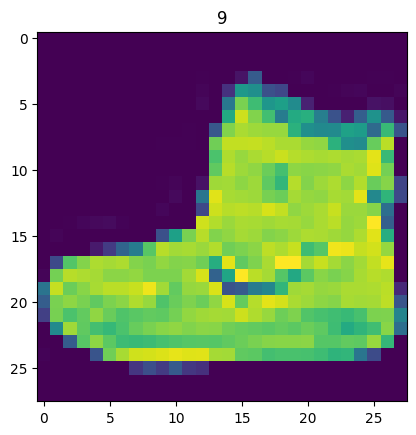

In [8]:
import matplotlib.pyplot as plt 
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())   #Image shape is [1, 28, 28] (color channels, height, width) 
plt.title(label);

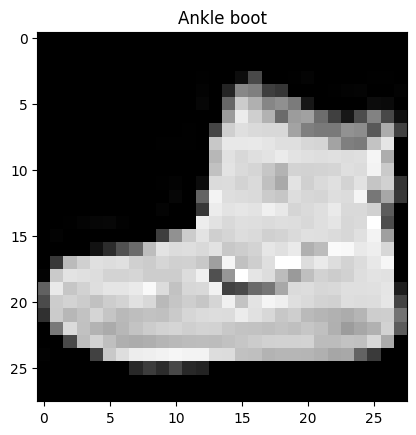

In [9]:
plt.imshow(image.squeeze(), cmap="gray")   #Image shape is [1, 28, 28] (color channels, height, width) 
plt.title(class_names[label]);

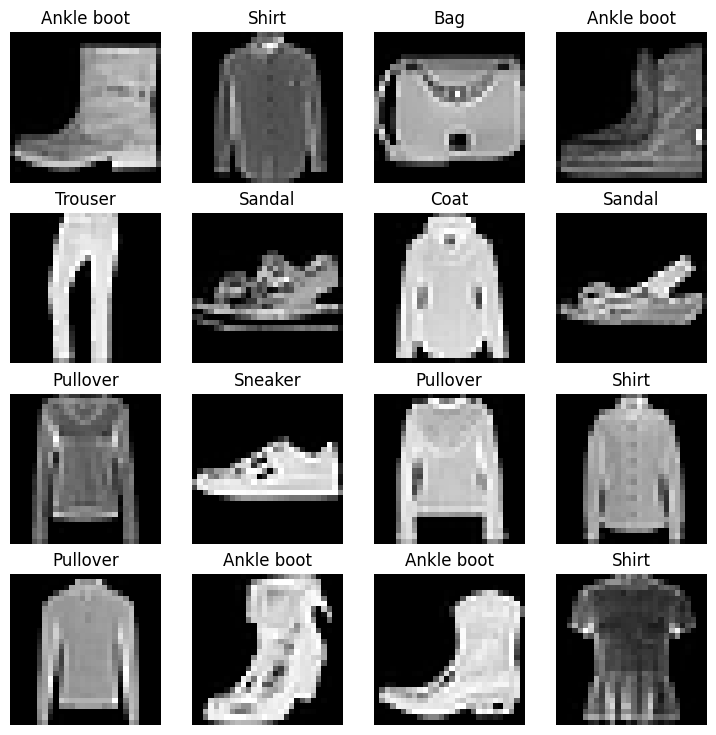

In [10]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols +1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

## 2.Prepare DataLoader

Now we've got a dataset ready to go.

The next step is to prepare it with a `torch.utils.data.DataLoader` or `DataLoader` for short.

The `DataLoader` does what you think it might do.

It helps load data into a model.

For training and for inference.

It turns a large Dataset into a Python iterable of smaller chunks.

These smaller chunks are called **batches** or **mini-batches** and can be set by the `batch_size` parameter.

Why do this?

Because it's more computationally efficient.

In an ideal world you could do the forward pass and backward pass across all of your data at once.

But once you start using really large datasets, unless you've got infinite computing power, it's easier to break them up into batches.

It also gives your model more opportunities to improve.

With **mini-batches** (small portions of the data), gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch).

What's a good batch size?

**32 is a good to start** for a fair amount of problems.

But since this is a value you can set (a **hyperparameter**) you can try all different kinds of values, though generally power of 2 are used most often (e.g 32, 64, 128, 256, 512).

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-batching-fashionmnist.png)



In [11]:
from torch.utils.data import DataLoader 

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables(batches)
train_dataloader = DataLoader(train_data, # Dataset to turn into iterable
    batch_size = BATCH_SIZE, # How many samples per batch?
    shuffle = True # Shuffle data every epoch?
)

test_dataloader = DataLoader(test_data, 
    batch_size=BATCH_SIZE,
    shuffle = False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)}, batches of {BATCH_SIZE}...")
print(f"Length of test dataloader: {len(test_dataloader)}, batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x138e20c40>, <torch.utils.data.dataloader.DataLoader object at 0x138db6800>)
Length of train dataloader: 1875, batches of 32...
Length of test dataloader: 313, batches of 32...


In [12]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


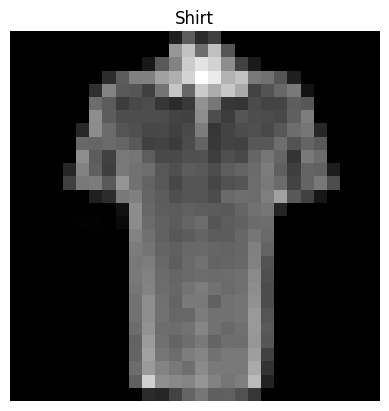

In [13]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## 3. Model 0: Build a baseline model

Data loaded are prepared!

Time to build a **baseline model** by subclassing `nn.Module`.

A **`baseline model`** is one of hte simplest models you can image.

You use the baseline as a string point and try to improve upon it with subsequent, more complicated models.

Our baseline will consist of two `nn.Linear()` layers.

We've done this in a previous section but there's going to one slight difference.

Because we're working with image data, we're going to use a different layer to start things off.

And that's the `nn.Flatten()` layer.

`nn.Flatern()` compresses the dimensions of a tensor into a single vector.

In [14]:
# Create a flatten layer
flatten_model = nn.Flatten()

# get a single sample
x = train_features_batch[0]

# Flatten the sample 
output = flatten_model(x)   # perform forward pass

# Print out what happed 
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
# print(x)
# print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


The `nn.Flatten()` layer took our shape from `[color_channels, height, width]` to `[color_channels, height*width]`.

Why do this?

Because we've now turned our pixel data from height and width dimensions into one long **feature vector**.

And `nn.Linear()` layers like their inputs to be in the from of feature vectors.

Let's create our first model using `nn.Flatten()` as the first layer.

In [15]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, 
                input_shape : int, 
                hidden_units : int,
                output_shape : int):
                super().__init__()
                self.layer_stack = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(in_features=input_shape, out_features=hidden_units),
                    nn.Linear(in_features=hidden_units, out_features=output_shape)
                )

    def forward(self, x):
        return self.layer_stack(x)

We've got a baseline model class we can use, now let's instantiate a model.

We'll need to set the following parameters:

* `input_shape=784` - this is how many features you've got going in the model, in our case, it's one for every pixel in the target image (28 pixels high by 28 pixels wide = 784 features).
* `hidden_units=10` - number of units/neurons in the hidden layer(s), this number could be whatever you want but to keep the model small we'll start with `10`.

* `output_shape=len(class_names)` - since we're working with a multi-class classification problem, we need an output neuron per class in our dataset.

Let's create an instance of our model and send to the CPU for now (we'll run a small test for running `model_0` on CPU vs. a similar model on GPU soon).

In [16]:
torch.manual_seed(42)

# Need to setup model with input parameters 
model_0 = FashionMNISTModelV0(
    input_shape = 28 * 28, # one for every pixel (28x28)
    hidden_units = 10, # how many units in the hiden layer
    output_shape = len(class_names)
).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 3.1 Stepup loss, optimizer and evaluation metrics

Since we're working on a classfication problem, let's bring in our `helper_function.py script` and subsequently the `accuracy_fn()`.

In [17]:
from helper_functions import accuracy_fn

# Setup loss and optimizer 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.1)

### 3.2 Creating a function to time our experiments

Loss function and optimizer ready!

It's time to start training a model.

But how about we do a little experiment while we train.

I mean, let's make a timing function to measure the time it takes our model to train on CPU versus using a GPU.

We'll train this model on the CPU but the next one on the GPU and see what happens.

Our timing function will import the [timeit.default_timer() function](https://docs.python.org/3/library/timeit.html#timeit.default_timer) from the Python [timeit module](https://docs.python.org/3/library/timeit.html).

In [18]:
from timeit import default_timer as timer 

def print_train_time(start: float, 
                    end: float, 
                    device: torch.device = None):

    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start 
    print(f"Train time on {device}: {total_time:.3f} seconds")

    return total_time

### 3.3 Creating a training loop and training a model on batches of data 

Looks like we've got all of the pieces of the puzzle ready to go, a timer, a loss function, an optimizer, a model and most importantly, some data.

Let's now create a training loop and a testing loop to train and evaluate our model.

Our data batches are contained within our `DataLoaders`, `train_dataloader` and `test_dataloader` for the training and test data splits respectively.

A batch is `BATCH_SIZE` samples of `X` (features) and `y` (labels), since we're using `BATCH_SIZE=32`, our batches have 32 samples of images and targets.

And since we're computing on batches of data, our loss and evaluation metrics will be calculated **per batch** rather than across the whole dataset.

This means we'll have to divide our loss and accuracy values by the number of batches in each dataset's respective dataloader.

Let's step through it:

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss per batch.
3. Loop through testing batches, perform testing steps, calculate the test loss per batch.
4. Print out what's happening.
5. Time it all (for fun).

A fair few steps but...

In [19]:
# Tmport tqdm for progress bar 
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epocha (we'll keep this small for faster training times)
epochs = 3

# Creating training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n------")

    ### Training 
    train_loss = 0

    # Add a loop to loop through training batches 
    for batch , (X, y) in enumerate(train_dataloader):
        model_0.train()

        # 1. Forward pass 
        y_pred = model_0(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # 3. Optimizer zero grad
        optimizer.zero_grad() 

        # 4. loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # print out how many samples have been seen 
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)

    ### Testing
    # setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass 
            test_pred = model_0(X)

            # 2. Calculate loss(accumatively)
            test_loss += loss_fn(test_pred, y)    # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true= y, y_pred=test_pred.argmax(dim=1))

        # Calculation on test metrics nedd to happen inside torch.inference_mode()
        # Devide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## print out what's happening 
    print(f"\n Training loss: {train_loss:.5f} | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")


# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_on_cpu, 
                                            end = train_time_end_on_cpu,
                                            device = str(next(model_0.parameters()).device))

/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:02<00:04,  2.39s/it]


 Training loss: 0.59039 | Test Loss: 0.50954, Test acc: 82.04%

Epoch: 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:04<00:02,  2.37s/it]


 Training loss: 0.47633 | Test Loss: 0.47989, Test acc: 83.20%

Epoch: 2
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:07<00:00,  2.34s/it]


 Training loss: 0.45503 | Test Loss: 0.47664, Test acc: 83.43%

Train time on cpu: 7.024 seconds


In [20]:
str(next(model_0.parameters()).device)

'cpu'

## Make predictions and get Model 0 results

Since we're goint to be building a few models, it's a good idea to write some code to evaluate them all in similar ways.

Namely, let's create a function that takes in a trained model, a `DataLoader`, a loss function and an accuracy function.

The function will use the model to maek prediction on the data in the `DataLoader` and then we can evaluate those predictions using the loss function and accuarcy function.

In [21]:
torch.manual_seed(42)

def eval_model(model:torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # make prediction with model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"Model Name" : model.__class__.__name__,
            "Model Loss" : loss.item(),
            "Model Accuracy" : acc }

# Calculate model 0 results on test dataset
model_0_results = eval_model(model = model_0, 
                            data_loader = test_dataloader,
                            loss_fn = loss_fn,
                            accuracy_fn=accuracy_fn)
model_0_results

{'Model Name': 'FashionMNISTModelV0',
 'Model Loss': 0.47663894295692444,
 'Model Accuracy': 83.42651757188499}

## 5. Setup device agnostic-code (for using a GPU if there is one)

**We've seen how long it make to train Pytorch model on 60,000 sample on CPU.**

Now let's setup some **device-agnostic code** for our models and data to run on GPU if it's available.

If you're running this notebook on Google Colab, and you don't a GPU turned on yet, it's now time to turn one on via **Runtime -> Change runtime type -> Hardware accelerator -> GPU**. If you do this, your runtime will likely reset and you'll have to run all of the cells above by going **Runtime -> Run before**.

In [22]:
# Setup device agnostic code 

device = torch.device("mps")
device

device(type='mps')

## 6.1 Model 1: Building a better model with non-linearity

We learned about the power of non-linearity.

Seeing the data we've been working with, do you think it needs non-linear functions?

And remember, linear means straight and non-linear means non-straight.

Let's find out.

We'll do so by recreating a similar model to before, except this time we'll put non-linear functions (`nn.ReLU()`) in between each linear layer.

In [23]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape:int, output_shape:int, hidden_unit:str):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features=hidden_unit, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x:torch.Tensor):
        return self.layer_stack(x)

We'll need `input_shape=784` (equal to the number of features of our image data), `hidden_units=10` (starting small and the same as our baseline model) and `output_shape=len``(class_names)` (one output unit per class).

In [24]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape = 28 *28, 
                              output_shape = len(class_names),
                              hidden_unit = 10).to(device)
    
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

### 6.1 Setup loss, optimizer and evaluation metrics

As usual, we'll setup a loss function, an optimizer and an evaluation metric (we could do multiple evaluation metrics but we'll stick with accuracy for now).

In [25]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.1)

### 6.2 Functionizing training and test loops

So far we've been writing train and test loops over and over.

Let's write them again but this time we'll put them in functions so they can be called again and again.

And because we're using device-agnostic code now, we'll be sure to call `.to(device)` on our feature (`X`) and target (`y`) tensors.

For the training loop we'll create a function called `train_step()` which takes in a model, a `DataLoader` a loss function and an optimizer.

The testing loop will be similar but it'll be called `test_step()` and it'll take in a model, a `DataLoader`, a loss function and an evaluation function.

In [26]:
def train_step(model:torch.nn.Module, 
               data_loader:torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer, 
               accuracy_fn,
               device: torch.device = device):

    train_loss, train_acc = 0, 0
    model.train()

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss 
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad 
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}%")


In [27]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device = device):
    
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() #put model in eval mode
    
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # 1. Forward pass 
            test_pred = model(X)

            # 2. Calculate loss and accuracy 
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        
        # Adjust metric and print output
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%\n")

In [28]:
torch.manual_seed(42)

# Mesure time 
from timeit import default_timer as timer 
train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n----")
    train_step(model=model_1, 
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer, 
               accuracy_fn = accuracy_fn,
               device = device)

    test_step(model = model_1,
             data_loader = test_dataloader, 
             loss_fn = loss_fn,
             accuracy_fn = accuracy_fn,
             device = device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----
Train Loss: 1.09199 | Train Accuracy: 61.34%


 33%|███▎      | 1/3 [00:08<00:16,  8.33s/it]

Test Loss: 0.95636 | Test Accuracy: 65.00%

Epoch: 1
----
Train Loss: 0.78097 | Train Accuracy: 71.94%


 67%|██████▋   | 2/3 [00:16<00:08,  8.08s/it]

Test Loss: 0.72611 | Test Accuracy: 73.99%

Epoch: 2
----
Train Loss: 0.67040 | Train Accuracy: 75.94%


100%|██████████| 3/3 [00:24<00:00,  8.05s/it]

Test Loss: 0.69007 | Test Accuracy: 74.81%

Train time on mps: 24.161 seconds


In [29]:
torch.manual_seed(42)

def eval_model(model:torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device:torch.device = device):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """

    loss, acc = 0, 0 
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X, y = X.to(device), y.to(device)

            # 1. forward pass 
            y_pred = model(X)

            # 2. Calculate loss and accuracy
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        acc /= len(data_loader)
        loss /= len(data_loader)

    return {"Model Name" : model.__class__.__name__,
            "Model Loss" : loss.item(),
            "Model Accuracy" : acc }

In [30]:
model_1_results = eval_model(model=model_1, 
           data_loader = test_dataloader, 
           loss_fn = loss_fn,
           accuracy_fn = accuracy_fn)
model_1_results

100%|██████████| 313/313 [00:00<00:00, 429.75it/s]


{'Model Name': 'FashionMNISTModelV1',
 'Model Loss': 0.6900656223297119,
 'Model Accuracy': 74.810303514377}

In [31]:
model_0_results

{'Model Name': 'FashionMNISTModelV0',
 'Model Loss': 0.47663894295692444,
 'Model Accuracy': 83.42651757188499}

## 7. Model 2: Building a convolutional Neural Network (CNN)

ALright, time to step things up a notch

It's time to create a Convolutional neural netwok(CNN or CovNet)

CNN's are known for their capabilities to find patterns in visual data.

And since we're dealing with visual data, let's see if using a CNN model can improve upon our baseline.

It follows the typical structure of a convolutional neural network:

**`Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer`**

### What model should I use?

Question: wait, you say CNN's are good for images, are there any other model types I should be aware of?

This table is a good general guide for which model to use (though there are exceptions).

| Problem type | Model to use (generally) | Code Example |
| ---- | ---- | ---- |
| Structured data (Excel spreadsheets, row and column data) | Gradient boosted models, Random Forests, XGBoost | [sklearn.ensemble](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble), [XGBoost library](https://xgboost.readthedocs.io/en/stable/) |
| Unstructured data (images, audio, language) | Convolutinal Neural Networks, Transformers | [torchvision.models](https://pytorch.org/vision/stable/models.html), [Huggingface Transformers](https://huggingface.co/docs/transformers/index) |

In [32]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels = input_shape,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.MaxPool2d(kernel_size=2,
                stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*7*7, # Calculate 
                out_features = output_shape
            )
        )
    def forward(self, x):
        x = self.block_1(x)
        # print(f" Output shape of conv_block_1: {x.shape}")
        x = self.block_2(x)
        # print(f" Output shape of conv_block_2: {x.shape}")
        x = self.classifier(x)
        return x

In [33]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
                            input_shape = 1,
                            hidden_units = 10,
                            output_shape = len(class_names)
                        ).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [34]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor

tensor([[[-7.9311e-02,  1.6144e+00, -4.6171e-01, -5.7414e-01,  5.1842e-01,
          -4.8354e-01,  1.3702e+00,  1.8823e-01, -6.3737e-01,  8.7616e-02,
           1.1489e+00,  8.7162e-01,  2.0577e-01, -1.0062e+00,  1.1125e+00,
          -7.4517e-01, -2.3947e-01,  7.5288e-01, -6.6769e-01,  5.5451e-01,
           9.0538e-01,  1.7207e+00,  3.2258e-01,  5.4998e-01,  1.3368e+00,
           9.1989e-01,  2.9305e-01,  7.0214e-01],
         [-1.0596e+00, -2.2214e+00,  7.0677e-01, -2.1389e-01, -1.0270e+00,
          -5.2316e-01,  1.4774e+00,  3.0483e-01, -6.4894e-01,  4.9036e-01,
          -2.8043e-01,  9.4100e-01, -8.9237e-01, -3.5752e-01,  1.0479e-01,
           4.1266e-02,  3.3505e-01, -2.4310e-01, -6.5055e-01, -3.3003e-01,
          -3.1443e-01, -1.3658e+00,  3.5626e-02, -4.3072e-01, -9.8891e-01,
          -1.0607e+00,  7.0623e-01, -2.2878e-01],
         [ 7.1535e-01,  4.1778e-01,  3.6404e-01, -1.6342e+00,  5.9972e-01,
          -3.3900e-01,  1.5490e-01, -2.7944e-01, -5.9674e-01,  2.4182e-02,


In [35]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0403, -0.0893,  0.0712, -0.0433,  0.0031,  0.0350,  0.0212,  0.0140,
         -0.0008, -0.0077]], device='mps:0', grad_fn=<LinearBackward0>)

### 7.1 Stepping through `nn.Conv2d()`

We could start using our model above and see what happens but let's first step through the two new layers we've added:

* `nn.Conv2d()`, also known as a convolutional layer.
* `nn.MaxPool2d()`, also known as a max pooling layer.

**Question** What does the "2d" in `nn.Conv2d()` stand for?

The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.

For other dimensional data (such as 1D for text or 3D for 3D objects) there's also nn.`Conv1d()` and `nn.Conv3d()`.

In [36]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

Let's create an example `nn.Conv2d()` with various parameters:

* `in_channels (int)` - Number of channels in the input image.
* `out_channels (int)` - Number of channels produced by the convolution.
* `kernel_size (int or tuple)` - Size of the convolving kernel/filter.
* `stride (int or tuple, optional)` - How big of a step the convolving kernel takes at a time. Default: 1.
* `padding (int, tuple, str)` - Padding added to all four sides of input. Default: 0.


In [37]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input) 

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

If we try to pass a single image in, we get a shape mismatch error:

`RuntimeError: Expected 4-dimensional input for 4-dimensional weight [10, 3, 3, 3], but got 3-dimensional input of size [3, 64, 64] instead`

This is because our `nn.Conv2d()` layer expects a 4-dimensional tensor as input with size (`N, C, H, W`) or [`batch_size, color_channels, height, width`].

Right now our single image `test_image` only has a shape of [`color_channels, height, width`] or [`3, 64, 64`].

We can fix this for a single image using `test_image.unsqueeze(dim=0)` to add an extra dimension for `N`.

In [38]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [39]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [40]:
# What if we changed the values of conv_layer?

torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(3, 3), # kernel is usually a square so a tuple also works
                         stride=1,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

Now let's check out what happens when we move data through nn.MaxPool2d().

In [41]:
test_image.shape

torch.Size([3, 64, 64])

In [42]:
# Primt out original image shape without and with unsqueezed dimesion
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPool2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


In [43]:
torch.manual_seed(42)
random_tensor = torch.randn(size=(1,1,2,2))
print(f"\n Random tensor: {random_tensor}")
print(f"\n Random tensor Shape: {random_tensor.shape}")

# Create max pool layers 
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass through tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax Pool tensor:\n {max_pool_tensor}")
print(f"Max Pool tensor shape: {max_pool_tensor.shape}")


 Random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

 Random tensor Shape: torch.Size([1, 1, 2, 2])

Max Pool tensor:
 tensor([[[[0.3367]]]])
Max Pool tensor shape: torch.Size([1, 1, 1, 1])


### 7.3 Setup a loss and optimizer for `model_2`

We've stepped through the layers in our first CNN enough.

But remember, if something still isn't clear, try starting small. 

Pick a single layer of a model, pass some data through it and see what happens.

Now it's time to move forward and get to training!

We'll use the function as before, `nn.CrossEntropyLoss()` as the loss function(since we're working with multi-class classification data).

In [44]:
# Setup Loss and optimizer 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr = 0.1)
                            

### 7.4 Training and testing `model_2` using our training and test functions

Loss and optimizer ready!

Time to train and test.

We'll use our `train_step()` and `test_step()` functions we created before.

We'll also measure the time to compare it to our other models.

In [45]:
torch.mps.manual_seed(42)

# Measure time 
from timeit import default_timer as timer 
train_time_start_model_2 = timer()

# Traina and Test model
epochs = 3 
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n----------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start = train_time_start_model_2, 
                                            end = train_time_end_model_2,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------
Train Loss: 0.58000 | Train Accuracy: 78.99%


 33%|███▎      | 1/3 [00:09<00:18,  9.46s/it]

Test Loss: 0.42855 | Test Accuracy: 85.36%

Epoch: 1
----------
Train Loss: 0.35515 | Train Accuracy: 87.20%


 67%|██████▋   | 2/3 [00:18<00:09,  9.47s/it]

Test Loss: 0.34207 | Test Accuracy: 88.08%

Epoch: 2
----------
Train Loss: 0.31589 | Train Accuracy: 88.54%


100%|██████████| 3/3 [00:28<00:00,  9.49s/it]

Test Loss: 0.33121 | Test Accuracy: 88.02%

Train time on mps: 28.479 seconds


Woah! Looks like the convolutional and max pooling layers helped improve performance a little.

Let's evaluate `model_2`'s results with our `eval_model()` function.

In [46]:
model_2_results = eval_model(
    model = model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn,
    device = device
)
model_2_results

100%|██████████| 313/313 [00:00<00:00, 389.15it/s]


{'Model Name': 'FashionMNISTModelV2',
 'Model Loss': 0.3312114179134369,
 'Model Accuracy': 88.01916932907348}

## 8. Compare model results and training time 

We've trained three different models.

1. `model_0` - out baseline model with two `nn.Linear()` layers.
2. `model_1` - the same setup as our baseline model except with `nn.ReLU()` layers in between the `nn.Linear()` layers.
3. `model_2` - our first CNN model that mimics the TinyVGG architecture on the CNN Explainer website.

This is a regular practice in machine learning. 

Building multiple models and performing multiple training experiments to see which performs best. 

let's combine multiple our model results dictionaries into a DataFrame and find out. 

In [47]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,Model Name,Model Loss,Model Accuracy
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.690066,74.810304
2,FashionMNISTModelV2,0.331211,88.019169


In [48]:
# We can add the training time values too.

# Add training times to results comparison
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,Model Name,Model Loss,Model Accuracy,training_time
0,FashionMNISTModelV0,0.476639,83.426518,7.024230
1,FashionMNISTModelV1,0.690066,74.810304,24.161105
2,FashionMNISTModelV2,0.331211,88.019169,28.478641


### Performance-speed tradeoff

Something to be aware of in machine learning is the **performance-speed** tradeoff.

Generally, you get better performance out of a larger, more complex model (like we did with `model_2`).

However, this performance increase often comes at a sacrifice of training speed and inference speed.



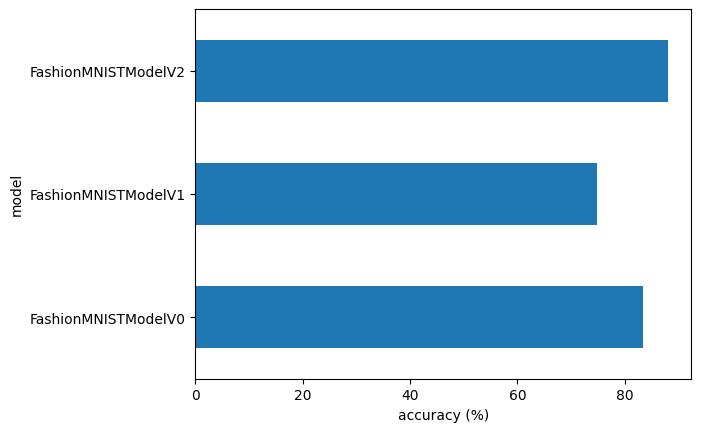

In [51]:
# Visualize our model results
compare_results.set_index("Model Name")["Model Accuracy"].plot(kind='barh')
plt.xlabel("accuracy (%)")
plt.ylabel("model");

## 9. Make and evaluate random predictions with best model

Alright, we've compared our models to each other, let's further evaluate our best performing model, `model_2`.

To do so, let's create a function `make_predictions()` where we can pass the model and some data for it to predict on.

In [58]:
def make_predictions(model:torch.nn.Module, data:list, device:torch.device=device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:

            # Prepare sample 
            sample = torch.unsqueeze(sample, dim=0).to(device)  # Add an extra dimension and send sample to device

            # Forward pass (model output raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> preditction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # return the pre_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [59]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


And now we can use our `make_predictions()` function to predict on `test_samples`.

In [60]:
# Make predictions on test samples with model 2

pred_probs = make_predictions(model = model_2, data=test_samples)
pred_probs[:2]

tensor([[8.4332e-07, 7.7286e-08, 3.5683e-07, 1.4346e-07, 1.1266e-08, 9.9958e-01,
         1.4544e-06, 1.8947e-05, 5.8162e-05, 3.3751e-04],
        [1.5422e-02, 8.9603e-01, 4.3518e-04, 4.0343e-02, 7.3236e-03, 9.2332e-05,
         3.9554e-02, 3.2932e-04, 2.7004e-04, 2.0239e-04]])

In [61]:
# Turn the prediction probabilities into prediction labels by taking the argmax()

pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [65]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

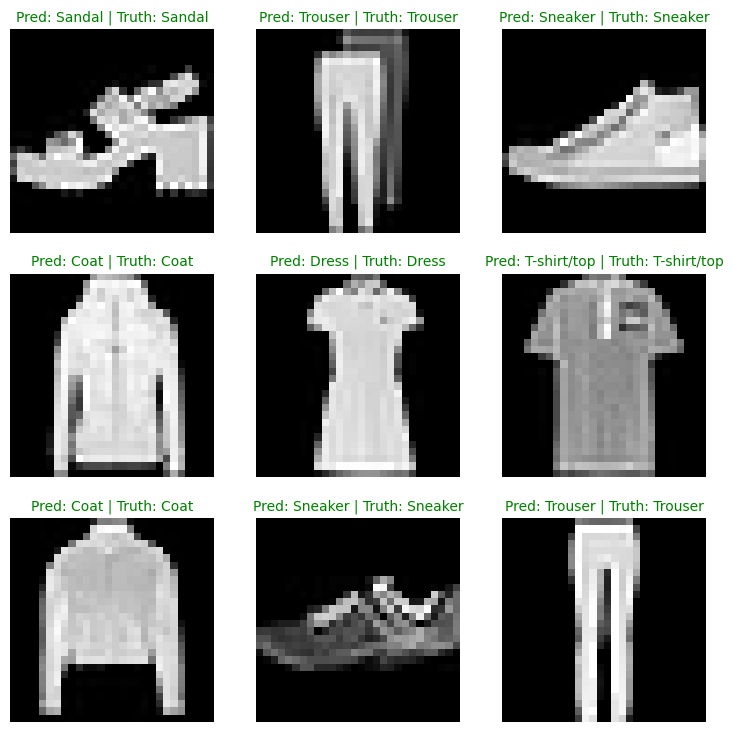

In [70]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create a subplot
    plt.subplot(nrows, ncols, i+1)

    # plot the target image
    plt.imshow(sample.squeeze(), cmap="gray")

    # Find the prediction label (in text from e.g. "sandle")
    pred_label = class_names[pred_classes[i]]

    # Get the truth label(in text from, e.g. "T-shirt")
    truth_label = class_names[test_labels[i]]

    # Create the title text of the plot 
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    # Check for quality and change title colour accordibgly 
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")

    plt.axis(False)

## 10. Making a confusion matrix for further prediction evaluation

There are many [different evaluation metrics](https://www.learnpytorch.io/02_pytorch_classification/#9-more-classification-evaluation-metrics) we can use for classification problems.

One of the most visual is a [confusion matrix](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/).

A confusion matrix shows you where your classification model got confused between predicitons and true labels.

To make a confusion matrix, we'll go through three steps:

1. Make predictions with our trained model, `model_2` (a confusion matrix compares predictions to true labels).
2. Make a confusion matrix using [torchmetrics.ConfusionMatrix](https://torchmetrics.readthedocs.io/en/latest/references/modules.html?highlight=confusion#confusionmatrix).
3. Plot the confusion matrix using [mlxtend.plotting.plot_confusion_matrix()](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/).

Let's start by making predictions with our trained model.

In [71]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 381.85it/s]


In [72]:
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1] >= 19), "mlxtend verison should be 0.19.0 or higher"

except:
    !pip install -q torchmetrics -U mlxtend
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.22.0


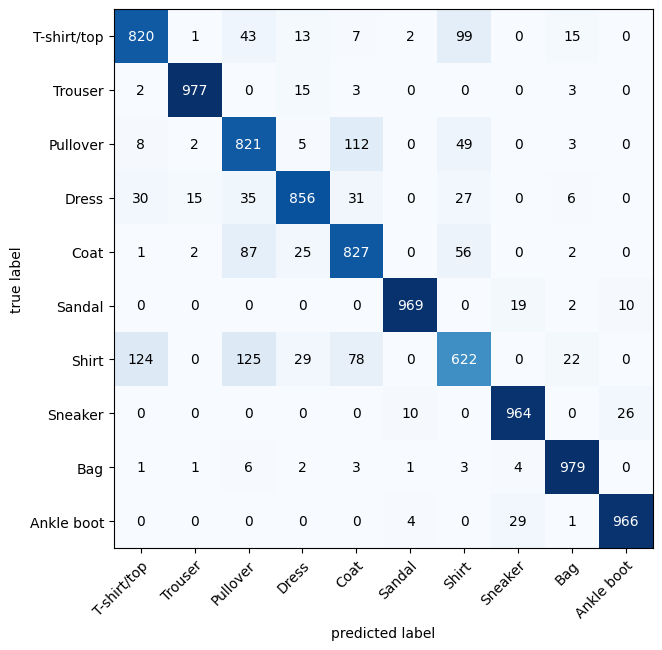

In [74]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion metrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes = len(class_names), task="multiclass")
confmat_tensor = confmat(preds = y_pred_tensor,
                         target=test_data.targets)

# Plot the confusion matrix
fir , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_names,
    figsize=(10,7)
);

## 11. Save and load best performing model

Let's finish this section off by saving and loading in our best performing model.

* `torch.save` - a function to save a whole PyTorch model or a model's `state_dict()`.
* `torch.load` - a function to load in a saved PyTorch object.
* `torch.nn.Module.load_state_dict()` - a function to load a saved `state_dict()` into an existing model instance.

You can see more of these three in the [PyTorch saving and loading models documentation](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

For now, let's save our `model_2`'s `state_dict()` then load it back in and evaluate it to make sure the save and load went correctly.

In [75]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


Now we've got a saved model `state_dict()` we can load it back in using a combination of `load_state_dict()` and `torch.load()`.

Since we're using `load_state_dict()`, we'll need to create a new instance of `FashionMNISTModelV2()` with the same input parameters as our saved model `state_dict()`.

In [76]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
loaded_model_2 = FashionMNISTModelV2(input_shape=1, 
                                    hidden_units=10, # try changing this to 128 and seeing what happens 
                                    output_shape=10) 

# Load in the saved state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send model to GPU
loaded_model_2 = loaded_model_2.to(device)

In [77]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

100%|██████████| 313/313 [00:00<00:00, 365.23it/s]


{'Model Name': 'FashionMNISTModelV2',
 'Model Loss': 0.3312114179134369,
 'Model Accuracy': 88.01916932907348}

In [78]:
model_2_results

{'Model Name': 'FashionMNISTModelV2',
 'Model Loss': 0.3312114179134369,
 'Model Accuracy': 88.01916932907348}

We can find out if two tensors are close to each other using `torch.isclose()` and passing in a tolerance level of closeness via the parameters `atol` (absolute tolerance) and `rtol` (relative tolerance).

If our model's results are close, the output of `torch.isclose()` should be true.

In [80]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_2_results["Model Loss"]), 
              torch.tensor(loaded_model_2_results["Model Loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)